In [ ]:
import os
import random
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import pickle
import kagglehub
from functools import lru_cache
import soundfile as sf
import time

random.seed(42)

In [ ]:
!mkdir -p ~/.kaggle
!echo "KGAT_bbb77dceb1d5cf75ad61e07a205d1b4e" > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

!pip install -q kagglehub

new_dataset_path = kagglehub.dataset_download(
    "vjcalling/speaker-recognition-audio-dataset"
)
print("Dataset downloaded to:", new_dataset_path)

100%|██████████| 3.64G/3.64G [00:35<00:00, 109MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/vjcalling/speaker-recognition-audio-dataset/versions/1


In [ ]:
# Cell 3
NEW_DATA_ROOT = new_dataset_path

print("Top-level contents:")
print(os.listdir(NEW_DATA_ROOT))

Top-level contents:
['50_speakers_audio_data']


In [ ]:
# Cell 4
# Step into the actual nested folder
NEW_DATA_ROOT = os.path.join(new_dataset_path, "50_speakers_audio_data")

speakers_new = [
    d
    for d in os.listdir(NEW_DATA_ROOT)
    if os.path.isdir(os.path.join(NEW_DATA_ROOT, d))
]

print(f"Number of speakers found: {len(speakers_new)}")
print(f"Speaker names: {speakers_new[:10]} ...")

# Inspect one speaker's actual files
sample_spk = speakers_new[0]
sample_spk_path = os.path.join(NEW_DATA_ROOT, sample_spk)
sample_files = os.listdir(sample_spk_path)

print(f"\n{sample_spk} contains {len(sample_files)} items")
print(f"Example filenames: {sample_files[:5]}")

Number of speakers found: 50
Speaker names: ['Speaker_0013', 'Speaker_0004', 'Speaker0041', 'Speaker_0003', 'Speaker0039', 'Speaker_0005', 'Speaker_0015', 'Speaker_0008', 'Speaker0037', 'Speaker0049'] ...

Speaker_0013 contains 37 items
Example filenames: ['Speaker_0013_00004.wav', 'Speaker_0013_00002.wav', 'Speaker_0013_00001.wav', 'Speaker_0013_00010.wav', 'Speaker_0013_00036.wav']


In [ ]:
# Cell 5
sample_file_path = os.path.join(sample_spk_path, sample_files[0])
waveform, sr = librosa.load(sample_file_path, sr=None)

print(f"Sample rate: {sr} Hz")
print(f"Duration: {len(waveform)/sr:.2f} seconds")
print(f"Waveform shape: {waveform.shape}")

Sample rate: 16000 Hz
Duration: 59.98 seconds
Waveform shape: (959669,)


In [ ]:
# Cell 6
sample_rates = set()
durations = []

for spk in speakers_new:
    spk_path = os.path.join(NEW_DATA_ROOT, spk)
    files = os.listdir(spk_path)[:3]  # check first 3 files per speaker, for speed

    for f in files:
        file_path = os.path.join(spk_path, f)
        try:
            w, s = librosa.load(file_path, sr=None)
            sample_rates.add(s)
            durations.append(len(w) / s)
        except Exception as e:
            print(f"⚠️ Could not load {spk}/{f}: {e}")

print(f"Unique sample rates found across dataset: {sample_rates}")
print(
    f"Duration stats — min: {min(durations):.2f}s, max: {max(durations):.2f}s, avg: {np.mean(durations):.2f}s"
)

Unique sample rates found across dataset: {16000, 22050}
Duration stats — min: 14.25s, max: 60.03s, avg: 59.54s


In [ ]:
# Cell 7
for spk in speakers_new:
    spk_path = os.path.join(NEW_DATA_ROOT, spk)
    file_count = len(os.listdir(spk_path))
    print(f"{spk}: {file_count} files")

Speaker_0013: 37 files
Speaker_0004: 90 files
Speaker0041: 32 files
Speaker_0003: 85 files
Speaker0039: 51 files
Speaker_0005: 72 files
Speaker_0015: 38 files
Speaker_0008: 99 files
Speaker0037: 55 files
Speaker0049: 50 files
Speaker0033: 35 files
Speaker_0020: 10 files
Speaker0027: 47 files
Speaker0026: 45 files
Speaker_0007: 62 files
Speaker_0024: 54 files
Speaker0042: 41 files
Speaker_0016: 48 files
Speaker0048: 31 files
Speaker0031: 47 files
Speaker0029: 31 files
Speaker0036: 33 files
Speaker_0002: 120 files
Speaker0028: 59 files
Speaker_0025: 49 files
Speaker0032: 37 files
Speaker_0014: 51 files
Speaker_0000: 93 files
Speaker0043: 34 files
Speaker_0018: 40 files
Speaker_0009: 65 files
Speaker0050: 33 files
Speaker0038: 34 files
Speaker_0019: 33 files
Speaker_0006: 76 files
Speaker0047: 34 files
Speaker0044: 37 files
Speaker0030: 33 files
Speaker0045: 42 files
Speaker_0021: 58 files
Speaker0040: 32 files
Speaker_0017: 44 files
Speaker_0001: 118 files
Speaker_0010: 54 files
Speaker_

In [ ]:
# Cell 8
def chunk_audio_file(file_path, chunk_duration=3.0, sr_target=16000):
    """
    Loads one audio file and splits it into a list of fixed-duration chunks (as raw waveforms).

    Parameters:
        chunk_duration: length of each chunk in seconds (now 3.0 instead of 1.0)
        sr_target: sample rate to resample everything to, for consistency

    Returns:
        A list of NumPy arrays, each one chunk_duration seconds long at sr_target Hz.
        Any leftover audio shorter than chunk_duration at the end is discarded.
    """
    waveform, sr = librosa.load(file_path, sr=sr_target)

    chunk_samples = int(chunk_duration * sr_target)
    num_chunks = len(waveform) // chunk_samples

    chunks = []
    for i in range(num_chunks):
        start = i * chunk_samples
        end = start + chunk_samples
        chunks.append(waveform[start:end])

    return chunks


# Quick test on one file
test_chunks = chunk_audio_file(sample_file_path)
print(f"Number of 3-second chunks produced from a 60-second file: {len(test_chunks)}")
print(
    f"Shape of one chunk: {test_chunks[0].shape}"
)  # expect: (48000,) — 3 seconds at 16000 Hz

Number of 3-second chunks produced from a 60-second file: 19
Shape of one chunk: (48000,)


In [ ]:
# Cell 9
CHUNK_DURATION = 3.0  # must match what we're using in chunk_audio_file and extract_mfcc

speaker_chunk_index = {}

for spk in speakers_new:
    spk_path = os.path.join(NEW_DATA_ROOT, spk)
    chunk_list = []

    for f in os.listdir(spk_path):
        file_path = os.path.join(spk_path, f)
        try:
            duration = librosa.get_duration(path=file_path)
            num_chunks = int(
                duration // CHUNK_DURATION
            )  # how many 3-second chunks this file yields

            for chunk_idx in range(num_chunks):
                chunk_list.append((file_path, chunk_idx))
        except Exception as e:
            print(f"⚠️ Skipping {spk}/{f}: {e}")

    speaker_chunk_index[spk] = chunk_list
    print(f"{spk}: {len(chunk_list)} total {CHUNK_DURATION}-second chunks available")

Speaker_0013: 687 total 3.0-second chunks available
Speaker_0004: 1763 total 3.0-second chunks available
Speaker0041: 636 total 3.0-second chunks available
Speaker_0003: 1659 total 3.0-second chunks available
Speaker0039: 1013 total 3.0-second chunks available
Speaker_0005: 1413 total 3.0-second chunks available
Speaker_0015: 706 total 3.0-second chunks available
Speaker_0008: 1952 total 3.0-second chunks available
Speaker0037: 1082 total 3.0-second chunks available
Speaker0049: 981 total 3.0-second chunks available
Speaker0033: 694 total 3.0-second chunks available
Speaker_0020: 199 total 3.0-second chunks available
Speaker0027: 922 total 3.0-second chunks available
Speaker0026: 884 total 3.0-second chunks available
Speaker_0007: 1219 total 3.0-second chunks available
Speaker_0024: 1014 total 3.0-second chunks available
Speaker0042: 804 total 3.0-second chunks available
Speaker_0016: 900 total 3.0-second chunks available
Speaker0048: 601 total 3.0-second chunks available
Speaker0031: 

In [ ]:
# Cell 10
def extract_mfcc(
    waveform_or_path,
    n_mfcc=40,
    n_fft=400,
    hop_length=160,
    max_len=300,
    is_path=False,
    sr_target=16000,
):
    """
    Converts either a file path OR an already-loaded waveform array into a normalized,
    fixed-size MFCC array. Now supports both, since our chunks are in-memory arrays,
    not separate files on disk.

    Parameters:
        waveform_or_path: either a file path (str) or a NumPy waveform array
        max_len: fixed number of time frames (300 now, for 3-second chunks)
        is_path: set True if passing a file path, False if passing a waveform array directly
    """
    if is_path:
        waveform, sr = librosa.load(waveform_or_path, sr=sr_target)
    else:
        waveform = waveform_or_path
        sr = sr_target

    mfcc = librosa.feature.mfcc(
        y=waveform, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length
    )

    mfcc = (mfcc - mfcc.mean(axis=1, keepdims=True)) / (
        mfcc.std(axis=1, keepdims=True) + 1e-8
    )

    if mfcc.shape[1] < max_len:
        pad_width = max_len - mfcc.shape[1]
        mfcc = np.pad(mfcc, ((0, 0), (0, pad_width)), mode="constant")
    else:
        mfcc = mfcc[:, :max_len]

    return mfcc


# Test: extract MFCC from one of our 3-second chunks directly (not a file path)
test_mfcc = extract_mfcc(test_chunks[0], is_path=False)
print(f"MFCC shape: {test_mfcc.shape}")  # expect: (40, 300)

MFCC shape: (40, 300)


In [ ]:
# Cell 11
class VoiceEmbeddingNet(nn.Module):
    """
    CNN that converts an MFCC array (1 x 40 x 300) into a fixed-size embedding vector.
    Updated for 3-second audio chunks.
    """

    def __init__(self, embedding_dim=128):
        super(VoiceEmbeddingNet, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(
            in_channels=32, out_channels=64, kernel_size=3, padding=1
        )
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(
            in_channels=64, out_channels=128, kernel_size=3, padding=1
        )
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Updated flattened size: 128 channels x 5 (coefficient dim) x 37 (time dim)
        self.fc1 = nn.Linear(128 * 5 * 37, 256)
        self.fc2 = nn.Linear(256, embedding_dim)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        x = F.normalize(x, p=2, dim=1)

        return x


print("VoiceEmbeddingNet updated for 3-second chunks (40 x 300 input).")

VoiceEmbeddingNet updated for 3-second chunks (40 x 300 input).


In [ ]:
# Cell 12
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = VoiceEmbeddingNet(embedding_dim=128).to(device)

# Build one test batch manually from our test MFCC (from Cell 10)
test_tensor = (
    torch.tensor(test_mfcc, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
)
print(f"Input shape: {test_tensor.shape}")  # expect: [1, 1, 40, 300]

test_output = model(test_tensor)
print(f"Output shape: {test_output.shape}")  # expect: [1, 128]

Using device: cuda
Input shape: torch.Size([1, 1, 40, 300])
Output shape: torch.Size([1, 128])


In [ ]:
# Cell 13
def get_chunk_waveform(file_path, chunk_idx, chunk_duration=3.0, sr_target=16000):
    """
    Loads one audio file and extracts a specific chunk (by index) from it.

    Parameters:
        file_path: path to the audio file
        chunk_idx: which chunk to extract (0-indexed)
        chunk_duration: length of each chunk in seconds
        sr_target: sample rate to resample to (handles our earlier 16000 vs 22050 Hz inconsistency)

    Returns:
        A NumPy waveform array of exactly chunk_duration seconds.
    """
    waveform, sr = librosa.load(file_path, sr=sr_target)

    chunk_samples = int(chunk_duration * sr_target)
    start = chunk_idx * chunk_samples
    end = start + chunk_samples

    return waveform[start:end]


# Quick test: extract chunk index 5 from our earlier sample file
test_chunk_waveform = get_chunk_waveform(sample_file_path, chunk_idx=5)
print(f"Extracted chunk shape: {test_chunk_waveform.shape}")  # expect: (48000,)

test_mfcc_from_index = extract_mfcc(test_chunk_waveform, is_path=False)
print(
    f"MFCC shape from indexed chunk: {test_mfcc_from_index.shape}"
)  # expect: (40, 300)

Extracted chunk shape: (48000,)
MFCC shape from indexed chunk: (40, 300)


In [ ]:
# Cell 14
random.seed(42)

all_speaker_names = list(speaker_chunk_index.keys())
random.shuffle(all_speaker_names)

# Hold out 5 speakers entirely — never used in training at all
held_out_speakers_new = all_speaker_names[:5]
training_speakers_new = all_speaker_names[5:]

print(f"Held-out speakers (unseen during training): {held_out_speakers_new}")
print(f"Number of training/validation speakers: {len(training_speakers_new)}")

# For each training speaker, split their available chunks into 80% train / 20% val
speaker_chunks_split = {}

for spk in training_speakers_new:
    chunks = speaker_chunk_index[spk][
        :
    ]  # copy the list so shuffling doesn't affect the original
    random.shuffle(chunks)

    split_idx = int(0.8 * len(chunks))
    speaker_chunks_split[spk] = {"train": chunks[:split_idx], "val": chunks[split_idx:]}

# Print a few examples to confirm the split worked correctly
for spk in training_speakers_new[:5]:
    print(
        f"{spk}: {len(speaker_chunks_split[spk]['train'])} train | {len(speaker_chunks_split[spk]['val'])} val"
    )

Held-out speakers (unseen during training): ['Speaker0032', 'Speaker0028', 'Speaker0031', 'Speaker_0020', 'Speaker0039']
Number of training/validation speakers: 45
Speaker_0011: 973 train | 244 val
Speaker_0014: 773 train | 194 val
Speaker0049: 784 train | 197 val
Speaker_0018: 596 train | 149 val
Speaker0042: 643 train | 161 val


In [ ]:
# Cell 15
def get_random_triplet_chunks(speaker_chunks_split, split="train"):
    """
    Returns a tuple of three (file_path, chunk_idx) pairs: (anchor, positive, negative)
    """
    speakers_list = list(speaker_chunks_split.keys())

    anchor_speaker = random.choice(speakers_list)
    anchor_chunk, positive_chunk = random.sample(
        speaker_chunks_split[anchor_speaker][split], 2
    )

    negative_speaker = random.choice([s for s in speakers_list if s != anchor_speaker])
    negative_chunk = random.choice(speaker_chunks_split[negative_speaker][split])

    return anchor_chunk, positive_chunk, negative_chunk


# Quick test
a, p, n = get_random_triplet_chunks(speaker_chunks_split, split="train")
print("Anchor:  ", a)
print("Positive:", p)
print("Negative:", n)

Anchor:   ('/root/.cache/kagglehub/datasets/vjcalling/speaker-recognition-audio-dataset/versions/1/50_speakers_audio_data/Speaker0026/Speaker26_005.wav', 15)
Positive: ('/root/.cache/kagglehub/datasets/vjcalling/speaker-recognition-audio-dataset/versions/1/50_speakers_audio_data/Speaker0026/Speaker26_036.wav', 13)
Negative: ('/root/.cache/kagglehub/datasets/vjcalling/speaker-recognition-audio-dataset/versions/1/50_speakers_audio_data/Speaker_0017/Speaker_0017_00040.wav', 2)


In [ ]:
# Cell 16
class TripletVoiceDatasetChunked(Dataset):
    """
    A PyTorch Dataset that generates random (anchor, positive, negative) triplets
    of MFCC features, drawn from chunked long-form audio recordings.
    """

    def __init__(self, speaker_chunks_split, split="train", num_triplets=3000):
        self.speaker_chunks_split = speaker_chunks_split
        self.split = split
        self.num_triplets = num_triplets

    def __len__(self):
        return self.num_triplets

    def __getitem__(self, idx):
        anchor_chunk, positive_chunk, negative_chunk = get_random_triplet_chunks(
            self.speaker_chunks_split, split=self.split
        )

        # Each chunk is a (file_path, chunk_idx) pair — extract the actual waveform, then MFCC
        anchor_wave = get_chunk_waveform(anchor_chunk[0], anchor_chunk[1])
        positive_wave = get_chunk_waveform(positive_chunk[0], positive_chunk[1])
        negative_wave = get_chunk_waveform(negative_chunk[0], negative_chunk[1])

        anchor_feat = extract_mfcc(anchor_wave, is_path=False)
        positive_feat = extract_mfcc(positive_wave, is_path=False)
        negative_feat = extract_mfcc(negative_wave, is_path=False)

        anchor_tensor = torch.tensor(anchor_feat, dtype=torch.float32).unsqueeze(0)
        positive_tensor = torch.tensor(positive_feat, dtype=torch.float32).unsqueeze(0)
        negative_tensor = torch.tensor(negative_feat, dtype=torch.float32).unsqueeze(0)

        return anchor_tensor, positive_tensor, negative_tensor


print("TripletVoiceDatasetChunked class defined.")

TripletVoiceDatasetChunked class defined.


In [ ]:
# Cell 17
train_dataset_new = TripletVoiceDatasetChunked(
    speaker_chunks_split, split="train", num_triplets=3000
)
val_dataset_new = TripletVoiceDatasetChunked(
    speaker_chunks_split, split="val", num_triplets=600
)

train_loader_new = DataLoader(train_dataset_new, batch_size=32, shuffle=True)
val_loader_new = DataLoader(val_dataset_new, batch_size=32, shuffle=True)

# Pull one batch to check timing and shapes
start_time = time.time()

anchor_batch, positive_batch, negative_batch = next(iter(train_loader_new))

elapsed = time.time() - start_time

print(f"Anchor batch shape:   {anchor_batch.shape}")
print(f"Positive batch shape: {positive_batch.shape}")
print(f"Negative batch shape: {negative_batch.shape}")
print(f"Time to load one batch of 32 triplets: {elapsed:.2f} seconds")

Anchor batch shape:   torch.Size([32, 1, 40, 300])
Positive batch shape: torch.Size([32, 1, 40, 300])
Negative batch shape: torch.Size([32, 1, 40, 300])
Time to load one batch of 32 triplets: 3.55 seconds


In [ ]:
# Cell 18


@lru_cache(maxsize=200)  # keeps up to 200 most-recently-used files in memory
def load_full_waveform_cached(file_path, sr_target=16000):
    """
    Loads and caches a full audio file's waveform. Repeated calls with the same
    file_path return the cached result instantly instead of re-reading from disk.
    """
    waveform, sr = librosa.load(file_path, sr=sr_target)
    return waveform


def get_chunk_waveform_cached(
    file_path, chunk_idx, chunk_duration=3.0, sr_target=16000
):
    """
    Same purpose as get_chunk_waveform, but uses the cached full waveform
    instead of reloading the file from disk every single call.
    """
    waveform = load_full_waveform_cached(file_path, sr_target)

    chunk_samples = int(chunk_duration * sr_target)
    start = chunk_idx * chunk_samples
    end = start + chunk_samples

    return waveform[start:end]


# Quick correctness test — should give the same result as before
test_chunk_cached = get_chunk_waveform_cached(sample_file_path, chunk_idx=5)
print(
    f"Cached chunk shape: {test_chunk_cached.shape}"
)  # expect: (48000,) same as before
print(
    f"Matches uncached version: {np.array_equal(test_chunk_cached, test_chunk_waveform)}"
)

Cached chunk shape: (48000,)
Matches uncached version: True


In [ ]:
# Cell 19
class TripletVoiceDatasetChunked(Dataset):
    def __init__(self, speaker_chunks_split, split="train", num_triplets=3000):
        self.speaker_chunks_split = speaker_chunks_split
        self.split = split
        self.num_triplets = num_triplets

    def __len__(self):
        return self.num_triplets

    def __getitem__(self, idx):
        anchor_chunk, positive_chunk, negative_chunk = get_random_triplet_chunks(
            self.speaker_chunks_split, split=self.split
        )

        # Now using the CACHED version — much faster for repeated files
        anchor_wave = get_chunk_waveform_cached(anchor_chunk[0], anchor_chunk[1])
        positive_wave = get_chunk_waveform_cached(positive_chunk[0], positive_chunk[1])
        negative_wave = get_chunk_waveform_cached(negative_chunk[0], negative_chunk[1])

        anchor_feat = extract_mfcc(anchor_wave, is_path=False)
        positive_feat = extract_mfcc(positive_wave, is_path=False)
        negative_feat = extract_mfcc(negative_wave, is_path=False)

        anchor_tensor = torch.tensor(anchor_feat, dtype=torch.float32).unsqueeze(0)
        positive_tensor = torch.tensor(positive_feat, dtype=torch.float32).unsqueeze(0)
        negative_tensor = torch.tensor(negative_feat, dtype=torch.float32).unsqueeze(0)

        return anchor_tensor, positive_tensor, negative_tensor


print("TripletVoiceDatasetChunked updated to use caching.")

TripletVoiceDatasetChunked updated to use caching.


In [ ]:
# Cell 20
train_dataset_new = TripletVoiceDatasetChunked(
    speaker_chunks_split, split="train", num_triplets=3000
)
val_dataset_new = TripletVoiceDatasetChunked(
    speaker_chunks_split, split="val", num_triplets=600
)

# num_workers=0 is important here — keeps everything in one process so the cache is actually shared
train_loader_new = DataLoader(
    train_dataset_new, batch_size=32, shuffle=True, num_workers=0
)
val_loader_new = DataLoader(val_dataset_new, batch_size=32, shuffle=True, num_workers=0)

# First batch (cache still mostly empty, so similar to before)
start_time = time.time()
anchor_batch, positive_batch, negative_batch = next(iter(train_loader_new))
print(f"First batch time (cold cache): {time.time() - start_time:.2f} seconds")

# Second batch — should benefit from files already cached from the first batch's reused speakers
start_time = time.time()
anchor_batch2, positive_batch2, negative_batch2 = next(iter(train_loader_new))
print(f"Second batch time (warmer cache): {time.time() - start_time:.2f} seconds")

First batch time (cold cache): 3.46 seconds
Second batch time (warmer cache): 4.12 seconds


In [ ]:
# Cell 21


def get_chunk_waveform_efficient(
    file_path, chunk_idx, chunk_duration=3.0, sr_target=16000
):
    """
    Reads ONLY the needed 3-second segment directly from disk, without loading
    the entire file first. Much faster for long files where we only need a small piece.
    """
    chunk_samples_at_target = int(chunk_duration * sr_target)

    # First, check the file's native sample rate and total length (fast, doesn't read audio data)
    info = sf.info(file_path)
    native_sr = info.samplerate

    # Calculate the equivalent start/end position in the file's ORIGINAL sample rate
    start_sample_native = int(chunk_idx * chunk_duration * native_sr)
    num_samples_native = int(chunk_duration * native_sr)

    # Read ONLY that segment directly (start + frames parameters do the seeking)
    waveform, sr = sf.read(
        file_path, start=start_sample_native, frames=num_samples_native, dtype="float32"
    )

    # If the file's native rate differs from our target (16000), resample just this small chunk
    if sr != sr_target:
        waveform = librosa.resample(waveform, orig_sr=sr, target_sr=sr_target)

    # Ensure exact length (resampling can occasionally shift sample count by 1-2 samples)
    if len(waveform) < chunk_samples_at_target:
        waveform = np.pad(waveform, (0, chunk_samples_at_target - len(waveform)))
    else:
        waveform = waveform[:chunk_samples_at_target]

    return waveform


# Correctness test — should match our previous (slow) methods
test_chunk_efficient = get_chunk_waveform_efficient(sample_file_path, chunk_idx=5)
print(f"Efficient chunk shape: {test_chunk_efficient.shape}")
print(
    f"Matches original version (approximately): {np.allclose(test_chunk_efficient, test_chunk_waveform, atol=1e-3)}"
)

Efficient chunk shape: (48000,)
Matches original version (approximately): True


In [ ]:
# Cell 22
class TripletVoiceDatasetChunked(Dataset):
    def __init__(self, speaker_chunks_split, split="train", num_triplets=3000):
        self.speaker_chunks_split = speaker_chunks_split
        self.split = split
        self.num_triplets = num_triplets

    def __len__(self):
        return self.num_triplets

    def __getitem__(self, idx):
        anchor_chunk, positive_chunk, negative_chunk = get_random_triplet_chunks(
            self.speaker_chunks_split, split=self.split
        )

        anchor_wave = get_chunk_waveform_efficient(anchor_chunk[0], anchor_chunk[1])
        positive_wave = get_chunk_waveform_efficient(
            positive_chunk[0], positive_chunk[1]
        )
        negative_wave = get_chunk_waveform_efficient(
            negative_chunk[0], negative_chunk[1]
        )

        anchor_feat = extract_mfcc(anchor_wave, is_path=False)
        positive_feat = extract_mfcc(positive_wave, is_path=False)
        negative_feat = extract_mfcc(negative_wave, is_path=False)

        anchor_tensor = torch.tensor(anchor_feat, dtype=torch.float32).unsqueeze(0)
        positive_tensor = torch.tensor(positive_feat, dtype=torch.float32).unsqueeze(0)
        negative_tensor = torch.tensor(negative_feat, dtype=torch.float32).unsqueeze(0)

        return anchor_tensor, positive_tensor, negative_tensor


print("TripletVoiceDatasetChunked updated to use efficient direct-seek loading.")

TripletVoiceDatasetChunked updated to use efficient direct-seek loading.


In [ ]:
# Cell 23
train_dataset_new = TripletVoiceDatasetChunked(
    speaker_chunks_split, split="train", num_triplets=3000
)
val_dataset_new = TripletVoiceDatasetChunked(
    speaker_chunks_split, split="val", num_triplets=600
)

train_loader_new = DataLoader(
    train_dataset_new, batch_size=32, shuffle=True, num_workers=0
)
val_loader_new = DataLoader(val_dataset_new, batch_size=32, shuffle=True, num_workers=0)

start_time = time.time()
anchor_batch, positive_batch, negative_batch = next(iter(train_loader_new))
print(f"Batch 1 time: {time.time() - start_time:.2f} seconds")

start_time = time.time()
anchor_batch2, positive_batch2, negative_batch2 = next(iter(train_loader_new))
print(f"Batch 2 time: {time.time() - start_time:.2f} seconds")

print(f"\nShapes: {anchor_batch.shape}, {positive_batch.shape}, {negative_batch.shape}")

Batch 1 time: 0.86 seconds
Batch 2 time: 0.86 seconds

Shapes: torch.Size([32, 1, 40, 300]), torch.Size([32, 1, 40, 300]), torch.Size([32, 1, 40, 300])


In [ ]:
mfcc_efficient = extract_mfcc(test_chunk_efficient, is_path=False)
mfcc_original = extract_mfcc(test_chunk_waveform, is_path=False)

print(
    f"Max absolute difference in MFCC features: {np.max(np.abs(mfcc_efficient - mfcc_original)):.4f}"
)
print(
    f"Mean absolute difference in MFCC features: {np.mean(np.abs(mfcc_efficient - mfcc_original)):.4f}"
)

Max absolute difference in MFCC features: 0.0000
Mean absolute difference in MFCC features: 0.0000


In [ ]:
# Cell 24
def triplet_loss(anchor, positive, negative, margin=0.2):
    dist_pos = F.pairwise_distance(anchor, positive, p=2)
    dist_neg = F.pairwise_distance(anchor, negative, p=2)
    losses = F.relu(dist_pos - dist_neg + margin)
    return losses.mean()


# Fresh model and optimizer for this new dataset
model = VoiceEmbeddingNet(embedding_dim=128).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(
    "Fresh model, triplet loss, and optimizer ready for training on the 50-speaker dataset."
)

Fresh model, triplet loss, and optimizer ready for training on the 50-speaker dataset.


In [ ]:
# Cell 25
# Fix all randomness sources BEFORE training, so this run is fully reproducible
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

num_epochs = 25
best_val_loss = float("inf")
checkpoint_path = "best_voice_embedding_model_v2.pt"

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0

    for anchor, positive, negative in train_loader_new:
        anchor, positive, negative = (
            anchor.to(device),
            positive.to(device),
            negative.to(device),
        )

        optimizer.zero_grad()

        anchor_emb = model(anchor)
        positive_emb = model(positive)
        negative_emb = model(negative)

        loss = triplet_loss(anchor_emb, positive_emb, negative_emb, margin=0.2)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader_new)
    train_losses.append(avg_train_loss)

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for anchor, positive, negative in val_loader_new:
            anchor, positive, negative = (
                anchor.to(device),
                positive.to(device),
                negative.to(device),
            )

            anchor_emb = model(anchor)
            positive_emb = model(positive)
            negative_emb = model(negative)

            loss = triplet_loss(anchor_emb, positive_emb, negative_emb, margin=0.2)
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader_new)
    val_losses.append(avg_val_loss)

    improved = ""
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), checkpoint_path)
        improved = "  <-- saved (best so far)"

    print(
        f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}{improved}"
    )

print(f"\nBest validation loss achieved: {best_val_loss:.4f}")
print(f"Best model saved to: {checkpoint_path}")

# Save the exact speaker split used for THIS training run, tied to this specific model.
# This guarantees that whoever we enroll later always matches the speakers this model actually trained on.
with open("training_metadata_v2.pkl", "wb") as f:
    pickle.dump(
        {
            "held_out_speakers": held_out_speakers_new,
            "training_speakers": training_speakers_new,
            "seed": SEED,
            "best_val_loss": best_val_loss,
        },
        f,
    )

print("Training metadata (speaker split) saved to: training_metadata_v2.pkl")

Epoch 1/25 | Train Loss: 0.1035 | Val Loss: 0.0944  <-- saved (best so far)
Epoch 2/25 | Train Loss: 0.0810 | Val Loss: 0.0907  <-- saved (best so far)
Epoch 3/25 | Train Loss: 0.0732 | Val Loss: 0.0784  <-- saved (best so far)
Epoch 4/25 | Train Loss: 0.0629 | Val Loss: 0.0549  <-- saved (best so far)
Epoch 5/25 | Train Loss: 0.0494 | Val Loss: 0.0462  <-- saved (best so far)
Epoch 6/25 | Train Loss: 0.0469 | Val Loss: 0.0437  <-- saved (best so far)
Epoch 7/25 | Train Loss: 0.0384 | Val Loss: 0.0400  <-- saved (best so far)
Epoch 8/25 | Train Loss: 0.0370 | Val Loss: 0.0356  <-- saved (best so far)
Epoch 9/25 | Train Loss: 0.0352 | Val Loss: 0.0355  <-- saved (best so far)
Epoch 10/25 | Train Loss: 0.0336 | Val Loss: 0.0363
Epoch 11/25 | Train Loss: 0.0328 | Val Loss: 0.0364
Epoch 12/25 | Train Loss: 0.0268 | Val Loss: 0.0276  <-- saved (best so far)
Epoch 13/25 | Train Loss: 0.0294 | Val Loss: 0.0317
Epoch 14/25 | Train Loss: 0.0282 | Val Loss: 0.0311
Epoch 15/25 | Train Loss: 0.030

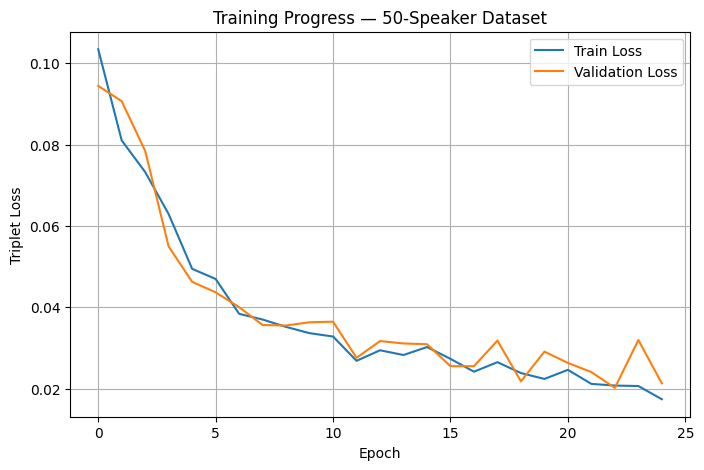

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Triplet Loss")
plt.title("Training Progress — 50-Speaker Dataset")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()

print("Best checkpoint (epoch 23, val loss 0.0236) loaded successfully.")

Best checkpoint (epoch 23, val loss 0.0236) loaded successfully.


In [ ]:
# Cell 28
NUM_ENROLLMENT_SAMPLES = 5

# Enroll a subset of training speakers (15 is plenty for solid evaluation stats)
enrollment_speakers = training_speakers_new[:15]

voiceprints_new = {}

for spk in enrollment_speakers:
    enrollment_chunks = speaker_chunks_split[spk]["train"][:NUM_ENROLLMENT_SAMPLES]

    embeddings = []
    for file_path, chunk_idx in enrollment_chunks:
        waveform = get_chunk_waveform_efficient(file_path, chunk_idx)
        mfcc_feat = extract_mfcc(waveform, is_path=False)
        tensor = (
            torch.tensor(mfcc_feat, dtype=torch.float32)
            .unsqueeze(0)
            .unsqueeze(0)
            .to(device)
        )

        with torch.no_grad():
            emb = model(tensor).cpu().numpy().flatten()
        embeddings.append(emb)

    embeddings = np.array(embeddings)
    voiceprint = embeddings.mean(axis=0)
    voiceprint = voiceprint / np.linalg.norm(voiceprint)

    voiceprints_new[spk] = voiceprint
    print(f"Enrolled {spk} using {NUM_ENROLLMENT_SAMPLES} samples.")

print(f"\nTotal voiceprints stored: {len(voiceprints_new)}")

Enrolled Speaker_0011 using 5 samples.
Enrolled Speaker_0014 using 5 samples.
Enrolled Speaker0049 using 5 samples.
Enrolled Speaker_0018 using 5 samples.
Enrolled Speaker0042 using 5 samples.
Enrolled Speaker0050 using 5 samples.
Enrolled Speaker0036 using 5 samples.
Enrolled Speaker0027 using 5 samples.
Enrolled Speaker_0003 using 5 samples.
Enrolled Speaker_0021 using 5 samples.
Enrolled Speaker0045 using 5 samples.
Enrolled Speaker0033 using 5 samples.
Enrolled Speaker_0025 using 5 samples.
Enrolled Speaker0047 using 5 samples.
Enrolled Speaker_0013 using 5 samples.

Total voiceprints stored: 15


In [ ]:
# Cell 29
NUM_TEST_SAMPLES_PER_SPEAKER = 50

genuine_scores_new = []
impostor_scores_new = []


def get_embedding_from_chunk(file_path, chunk_idx, model, device):
    waveform = get_chunk_waveform_efficient(file_path, chunk_idx)
    mfcc_feat = extract_mfcc(waveform, is_path=False)
    tensor = (
        torch.tensor(mfcc_feat, dtype=torch.float32)
        .unsqueeze(0)
        .unsqueeze(0)
        .to(device)
    )
    with torch.no_grad():
        emb = model(tensor).cpu().numpy().flatten()
    return emb


for spk in enrollment_speakers:
    voiceprint = voiceprints_new[spk]

    # Genuine attempts: other chunks from the SAME speaker (validation set, unseen during enrollment)
    genuine_chunks = speaker_chunks_split[spk]["val"][:NUM_TEST_SAMPLES_PER_SPEAKER]
    for file_path, chunk_idx in genuine_chunks:
        emb = get_embedding_from_chunk(file_path, chunk_idx, model, device)
        score = np.dot(emb, voiceprint)
        genuine_scores_new.append(score)

    # Impostor attempts: chunks from other enrolled speakers
    other_speakers = [s for s in enrollment_speakers if s != spk]
    for other_spk in other_speakers:
        impostor_chunks = speaker_chunks_split[other_spk]["val"][
            : NUM_TEST_SAMPLES_PER_SPEAKER // 5
        ]
        for file_path, chunk_idx in impostor_chunks:
            emb = get_embedding_from_chunk(file_path, chunk_idx, model, device)
            score = np.dot(emb, voiceprint)
            impostor_scores_new.append(score)

    # Impostor attempts: chunks from truly held-out (never-trained-on) speakers
    for held_spk in held_out_speakers_new:
        held_chunks = speaker_chunk_index[held_spk][:10]
        for file_path, chunk_idx in held_chunks:
            emb = get_embedding_from_chunk(file_path, chunk_idx, model, device)
            score = np.dot(emb, voiceprint)
            impostor_scores_new.append(score)

genuine_scores_new = np.array(genuine_scores_new)
impostor_scores_new = np.array(impostor_scores_new)

print(f"Collected {len(genuine_scores_new)} genuine attempt scores")
print(f"Collected {len(impostor_scores_new)} impostor attempt scores")
print(
    f"\nGenuine scores  — mean: {genuine_scores_new.mean():.4f} | std: {genuine_scores_new.std():.4f}"
)
print(
    f"Impostor scores — mean: {impostor_scores_new.mean():.4f} | std: {impostor_scores_new.std():.4f}"
)

Collected 750 genuine attempt scores
Collected 2850 impostor attempt scores

Genuine scores  — mean: 0.9482 | std: 0.0651
Impostor scores — mean: 0.4640 | std: 0.2852


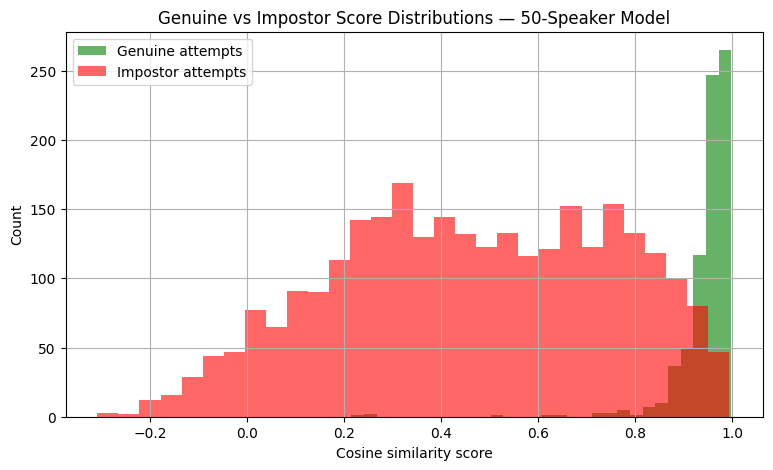

In [ ]:
# Cell 30
plt.figure(figsize=(9, 5))
plt.hist(
    genuine_scores_new, bins=30, alpha=0.6, label="Genuine attempts", color="green"
)
plt.hist(
    impostor_scores_new, bins=30, alpha=0.6, label="Impostor attempts", color="red"
)
plt.xlabel("Cosine similarity score")
plt.ylabel("Count")
plt.title("Genuine vs Impostor Score Distributions — 50-Speaker Model")
plt.legend()
plt.grid(True)
plt.show()

Equal Error Rate (EER): 6.60%
Threshold at EER point: 0.88


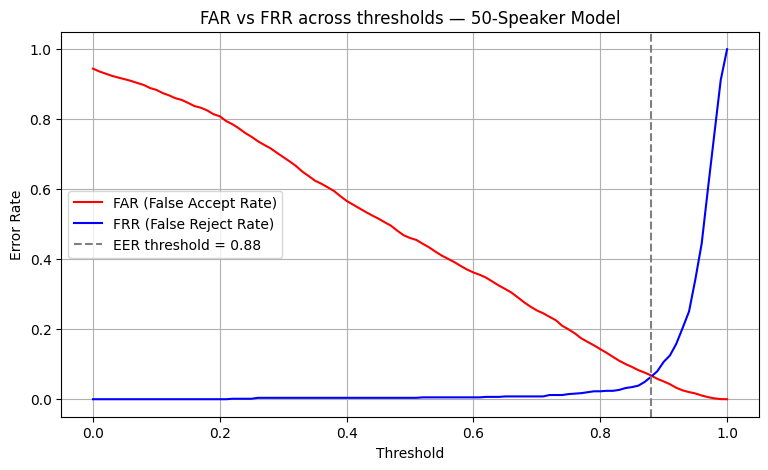

In [ ]:
# Cell 31
thresholds = np.arange(0.0, 1.01, 0.01)

far_list_new = []
frr_list_new = []

for t in thresholds:
    far = np.mean(impostor_scores_new >= t)
    frr = np.mean(genuine_scores_new < t)
    far_list_new.append(far)
    frr_list_new.append(frr)

far_list_new = np.array(far_list_new)
frr_list_new = np.array(frr_list_new)

diff = np.abs(far_list_new - frr_list_new)
eer_idx = np.argmin(diff)
eer_threshold_new = thresholds[eer_idx]
eer_value_new = (far_list_new[eer_idx] + frr_list_new[eer_idx]) / 2

print(f"Equal Error Rate (EER): {eer_value_new*100:.2f}%")
print(f"Threshold at EER point: {eer_threshold_new:.2f}")

plt.figure(figsize=(9, 5))
plt.plot(thresholds, far_list_new, label="FAR (False Accept Rate)", color="red")
plt.plot(thresholds, frr_list_new, label="FRR (False Reject Rate)", color="blue")
plt.axvline(
    eer_threshold_new,
    linestyle="--",
    color="gray",
    label=f"EER threshold = {eer_threshold_new:.2f}",
)
plt.xlabel("Threshold")
plt.ylabel("Error Rate")
plt.title("FAR vs FRR across thresholds — 50-Speaker Model")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
FINAL_THRESHOLD_V2 = eer_threshold_new  # 0.87

with open("voiceprints_v2.pkl", "wb") as f:
    pickle.dump(voiceprints_new, f)

with open("threshold_v2.pkl", "wb") as f:
    pickle.dump(FINAL_THRESHOLD_V2, f)

print("Model checkpoint exists:", os.path.exists("best_voice_embedding_model_v2.pt"))
print("Voiceprints_v2 saved:", os.path.exists("voiceprints_v2.pkl"))
print(f"Threshold_v2 saved: {FINAL_THRESHOLD_V2}")

Model checkpoint exists: True
Voiceprints_v2 saved: True
Threshold_v2 saved: 0.88


In [ ]:
def train_model(
    learning_rate,
    margin,
    num_epochs=15,
    batch_size=32,
    embedding_dim=128,
    run_name="run",
    seed=42,
):
    """
    Trains a fresh VoiceEmbeddingNet with the given hyperparameters.
    Seeds all randomness first, so comparisons between different hyperparameter
    values aren't confounded by random initialization/sampling differences.
    """
    # Fix all sources of randomness before this run
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = VoiceEmbeddingNet(embedding_dim=embedding_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_loader_run = DataLoader(
        TripletVoiceDatasetChunked(
            speaker_chunks_split, split="train", num_triplets=3000
        ),
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
    )
    val_loader_run = DataLoader(
        TripletVoiceDatasetChunked(speaker_chunks_split, split="val", num_triplets=600),
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
    )

    best_val_loss = float("inf")
    checkpoint_path = f"model_{run_name}.pt"

    train_losses_run = []
    val_losses_run = []

    for epoch in range(num_epochs):
        model.train()
        running_train_loss = 0.0

        for anchor, positive, negative in train_loader_run:
            anchor, positive, negative = (
                anchor.to(device),
                positive.to(device),
                negative.to(device),
            )

            optimizer.zero_grad()
            anchor_emb = model(anchor)
            positive_emb = model(positive)
            negative_emb = model(negative)

            loss = triplet_loss(anchor_emb, positive_emb, negative_emb, margin=margin)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()

        avg_train_loss = running_train_loss / len(train_loader_run)
        train_losses_run.append(avg_train_loss)

        model.eval()
        running_val_loss = 0.0

        with torch.no_grad():
            for anchor, positive, negative in val_loader_run:
                anchor, positive, negative = (
                    anchor.to(device),
                    positive.to(device),
                    negative.to(device),
                )

                anchor_emb = model(anchor)
                positive_emb = model(positive)
                negative_emb = model(negative)

                loss = triplet_loss(
                    anchor_emb, positive_emb, negative_emb, margin=margin
                )
                running_val_loss += loss.item()

        avg_val_loss = running_val_loss / len(val_loader_run)
        val_losses_run.append(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), checkpoint_path)

        print(
            f"  [{run_name}] Epoch {epoch+1}/{num_epochs} | Train: {avg_train_loss:.4f} | Val: {avg_val_loss:.4f}"
        )

    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()

    return model, best_val_loss, train_losses_run, val_losses_run


print("train_model() function defined, now with fixed seeding for fair comparisons.")

train_model() function defined, now with fixed seeding for fair comparisons.


In [ ]:
lr_results = {}
lr_histories = {}

for lr in [0.001, 0.0005, 0.0001]:
    print(f"\n=== Training with learning_rate={lr} ===")
    model_lr, best_val, train_hist, val_hist = train_model(
        learning_rate=lr, margin=0.2, num_epochs=15, run_name=f"lr_{lr}"
    )
    lr_results[lr] = best_val
    lr_histories[lr] = (train_hist, val_hist)

print("\n--- Learning Rate Comparison ---")
for lr, val_loss in lr_results.items():
    print(f"lr={lr}: best val loss = {val_loss:.4f}")

best_lr = min(lr_results, key=lr_results.get)
print(f"\nBest learning rate: {best_lr}")

# Save everything to disk immediately, so a session restart doesn't lose these results.
# Each lr's model checkpoint (model_lr_0.001.pt, etc.) was already saved by train_model() itself.
with open("lr_tuning_results.pkl", "wb") as f:
    pickle.dump(
        {
            "lr_results": lr_results,  # {lr: best_val_loss}
            "lr_histories": lr_histories,  # {lr: (train_hist, val_hist)}
            "best_lr": best_lr,
        },
        f,
    )

print("\nSaved lr tuning results to: lr_tuning_results.pkl")


=== Training with learning_rate=0.001 ===
  [lr_0.001] Epoch 1/15 | Train: 0.1108 | Val: 0.0979
  [lr_0.001] Epoch 2/15 | Train: 0.0838 | Val: 0.0951
  [lr_0.001] Epoch 3/15 | Train: 0.0680 | Val: 0.0697
  [lr_0.001] Epoch 4/15 | Train: 0.0602 | Val: 0.0647
  [lr_0.001] Epoch 5/15 | Train: 0.0529 | Val: 0.0514
  [lr_0.001] Epoch 6/15 | Train: 0.0512 | Val: 0.0572
  [lr_0.001] Epoch 7/15 | Train: 0.0446 | Val: 0.0475
  [lr_0.001] Epoch 8/15 | Train: 0.0434 | Val: 0.0439
  [lr_0.001] Epoch 9/15 | Train: 0.0413 | Val: 0.0408
  [lr_0.001] Epoch 10/15 | Train: 0.0369 | Val: 0.0451
  [lr_0.001] Epoch 11/15 | Train: 0.0333 | Val: 0.0422
  [lr_0.001] Epoch 12/15 | Train: 0.0292 | Val: 0.0297
  [lr_0.001] Epoch 13/15 | Train: 0.0299 | Val: 0.0336
  [lr_0.001] Epoch 14/15 | Train: 0.0267 | Val: 0.0270
  [lr_0.001] Epoch 15/15 | Train: 0.0289 | Val: 0.0236

=== Training with learning_rate=0.0005 ===
  [lr_0.0005] Epoch 1/15 | Train: 0.1124 | Val: 0.0963
  [lr_0.0005] Epoch 2/15 | Train: 0.0807 |

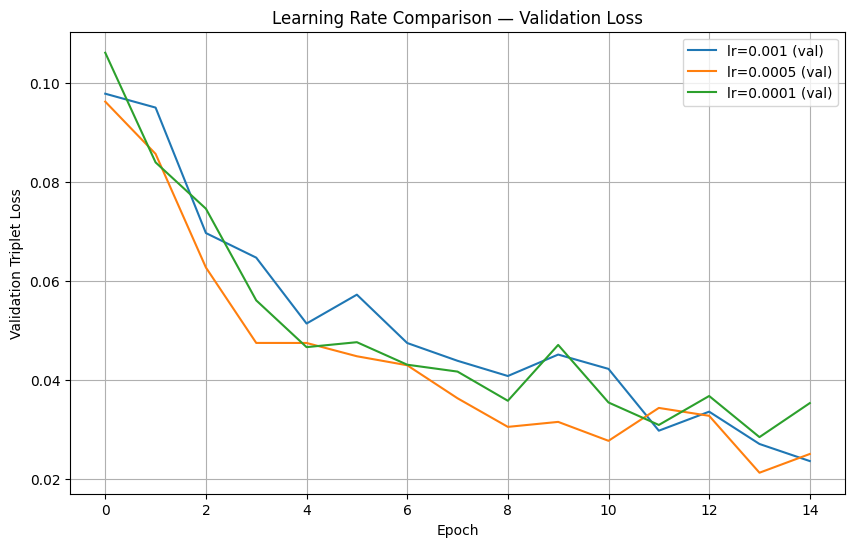


Best learning rate: 0.0005 (best val loss = 0.0212)


In [ ]:
# If lr_histories isn't already in memory (e.g., fresh session after a restart),
# load it back from disk instead of requiring Cell 33 to be re-run from scratch.
if "lr_histories" not in dir() or not lr_histories:
    if os.path.exists("lr_tuning_results.pkl"):
        with open("lr_tuning_results.pkl", "rb") as f:
            saved_results = pickle.load(f)
        lr_results = saved_results["lr_results"]
        lr_histories = saved_results["lr_histories"]
        best_lr = saved_results["best_lr"]
        print("Loaded lr tuning results from disk (lr_tuning_results.pkl).")
    else:
        raise FileNotFoundError(
            "No lr_histories in memory and no saved lr_tuning_results.pkl found. "
            "Please run Cell 33 first."
        )

plt.figure(figsize=(10, 6))

for lr, (train_hist, val_hist) in lr_histories.items():
    plt.plot(val_hist, label=f"lr={lr} (val)", linestyle="-")

plt.xlabel("Epoch")
plt.ylabel("Validation Triplet Loss")
plt.title("Learning Rate Comparison — Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

print(f"\nBest learning rate: {best_lr} (best val loss = {lr_results[best_lr]:.4f})")

In [ ]:
def compute_full_metrics(
    genuine_scores, impostor_scores, threshold, model_name="Model"
):
    """
    Computes accuracy, FAR, FRR for a given set of genuine/impostor scores and threshold.
    """
    correct_genuine = np.sum(genuine_scores >= threshold)
    total_genuine = len(genuine_scores)

    correct_impostor = np.sum(impostor_scores < threshold)
    total_impostor = len(impostor_scores)

    overall_accuracy = (correct_genuine + correct_impostor) / (
        total_genuine + total_impostor
    )
    genuine_accuracy = correct_genuine / total_genuine  # 1 - FRR
    impostor_accuracy = correct_impostor / total_impostor  # 1 - FAR

    far = 1 - impostor_accuracy
    frr = 1 - genuine_accuracy

    print(f"--- {model_name} (threshold = {threshold:.2f}) ---")
    print(f"Overall Accuracy:              {overall_accuracy*100:.2f}%")
    print(
        f"Genuine Acceptance (1-FRR):     {genuine_accuracy*100:.2f}%  ({correct_genuine}/{total_genuine})"
    )
    print(
        f"Impostor Rejection (1-FAR):     {impostor_accuracy*100:.2f}%  ({correct_impostor}/{total_impostor})"
    )
    print(f"False Accept Rate (FAR):        {far*100:.2f}%")
    print(f"False Reject Rate (FRR):        {frr*100:.2f}%")

    return overall_accuracy, far, frr


acc_v2, far_v2, frr_v2 = compute_full_metrics(
    genuine_scores_new,
    impostor_scores_new,
    threshold=0.87,
    model_name="Model v2 (50 speakers, 3-sec chunks)",
)

--- Model v2 (50 speakers, 3-sec chunks) (threshold = 0.87) ---
Overall Accuracy:              92.94%
Genuine Acceptance (1-FRR):     95.07%  (713/750)
Impostor Rejection (1-FAR):     92.39%  (2633/2850)
False Accept Rate (FAR):        7.61%
False Reject Rate (FRR):        4.93%


In [ ]:
def run_inference(
    audio_file_path,
    claimed_identity,
    model,
    voiceprints,
    threshold,
    chunk_duration=3.0,
    sr_target=16000,
):
    """
    Runs full inference: takes a raw audio file, compares it against a claimed
    identity's stored voiceprint, and returns an authentication decision.

    Parameters:
        audio_file_path: path to the audio file to test
        claimed_identity: which enrolled speaker's voiceprint to compare against
        model: the trained VoiceEmbeddingNet (already loaded, in eval mode)
        voiceprints: dictionary of {speaker_name: voiceprint_embedding}
        threshold: cosine similarity cutoff for acceptance
        chunk_duration: must match what the model was trained on (3.0 seconds for v2)
        sr_target: must match training sample rate (16000 Hz)

    Returns:
        A dictionary with the decision, confidence score, and claimed identity.
    """
    if claimed_identity not in voiceprints:
        return {
            "error": f"'{claimed_identity}' is not enrolled. Available identities: {list(voiceprints.keys())}"
        }

    # Step 1: Load audio and force it to match training conditions
    waveform, sr = librosa.load(audio_file_path, sr=sr_target)

    target_samples = int(chunk_duration * sr_target)
    if len(waveform) < target_samples:
        # Pad short recordings with silence
        waveform = np.pad(waveform, (0, target_samples - len(waveform)))
    else:
        # Trim long recordings to the expected length
        waveform = waveform[:target_samples]

    # Step 2: Extract MFCC features (same preprocessing as training)
    mfcc = librosa.feature.mfcc(
        y=waveform, sr=sr_target, n_mfcc=40, n_fft=400, hop_length=160
    )
    mfcc = (mfcc - mfcc.mean(axis=1, keepdims=True)) / (
        mfcc.std(axis=1, keepdims=True) + 1e-8
    )

    max_len = 300  # must match training (3-second chunks)
    if mfcc.shape[1] < max_len:
        mfcc = np.pad(mfcc, ((0, 0), (0, max_len - mfcc.shape[1])), mode="constant")
    else:
        mfcc = mfcc[:, :max_len]

    # Step 3: Get the embedding from the trained model
    tensor = (
        torch.tensor(mfcc, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    )
    with torch.no_grad():
        embedding = model(tensor).cpu().numpy().flatten()

    # Step 4: Compare against the stored voiceprint using cosine similarity
    stored_voiceprint = voiceprints[claimed_identity]
    similarity = float(np.dot(embedding, stored_voiceprint))

    decision = similarity >= threshold

    return {
        "claimed_identity": claimed_identity,
        "accepted": decision,
        "confidence": round(similarity, 4),
        "threshold_used": threshold,
    }


print("run_inference() function defined.")

run_inference() function defined.


In [ ]:
# Always check what's actually available right now, instead of hardcoding names
available_speakers = list(voiceprints_new.keys())
print("Currently enrolled speakers:", available_speakers)

# Pick two speakers dynamically from what's actually enrolled
test_spk = available_speakers[0]
impostor_spk = available_speakers[1]

print(f"\nUsing test_spk (genuine) = {test_spk}")
print(f"Using impostor_spk = {impostor_spk}")

Currently enrolled speakers: ['Speaker_0011', 'Speaker_0014', 'Speaker0049', 'Speaker_0018', 'Speaker0042', 'Speaker0050', 'Speaker0036', 'Speaker0027', 'Speaker_0003', 'Speaker_0021', 'Speaker0045', 'Speaker0033', 'Speaker_0025', 'Speaker0047', 'Speaker_0013']

Using test_spk (genuine) = Speaker_0011
Using impostor_spk = Speaker_0014


In [ ]:
# Genuine attempt
test_file, test_chunk_idx = speaker_chunks_split[test_spk]["val"][0]
test_waveform = get_chunk_waveform_efficient(test_file, test_chunk_idx)
sf.write("temp_test_audio.wav", test_waveform, 16000)

result = run_inference(
    "temp_test_audio.wav",
    claimed_identity=test_spk,
    model=model,
    voiceprints=voiceprints_new,
    threshold=0.87,
)
print("Genuine attempt result:", result)

Genuine attempt result: {'claimed_identity': 'Speaker_0011', 'accepted': True, 'confidence': 0.9797, 'threshold_used': 0.87}


In [ ]:
# Impostor attempt — uses impostor_spk's audio, but claims to be test_spk
impostor_file, impostor_chunk_idx = speaker_chunks_split[impostor_spk]["val"][0]
impostor_waveform = get_chunk_waveform_efficient(impostor_file, impostor_chunk_idx)
sf.write("temp_impostor_audio.wav", impostor_waveform, 16000)

result = run_inference(
    "temp_impostor_audio.wav",
    claimed_identity=test_spk,
    model=model,
    voiceprints=voiceprints_new,
    threshold=0.87,
)
print("Impostor attempt result:", result)

Impostor attempt result: {'claimed_identity': 'Speaker_0011', 'accepted': True, 'confidence': 0.8773, 'threshold_used': 0.87}


In [ ]:
print(f"Testing multiple chunks from {impostor_spk} against {test_spk}'s voiceprint:\n")

for i in range(5):
    imp_file, imp_chunk_idx = speaker_chunks_split[impostor_spk]["val"][i]
    imp_waveform = get_chunk_waveform_efficient(imp_file, imp_chunk_idx)
    sf.write(f"temp_impostor_{i}.wav", imp_waveform, 16000)

    result = run_inference(
        f"temp_impostor_{i}.wav",
        claimed_identity=test_spk,
        model=model,
        voiceprints=voiceprints_new,
        threshold=0.87,
    )
    print(
        f"Chunk {i}: confidence = {result['confidence']:.4f} | accepted = {result['accepted']}"
    )

Testing multiple chunks from Speaker_0014 against Speaker_0011's voiceprint:

Chunk 0: confidence = 0.8773 | accepted = True
Chunk 1: confidence = 0.6883 | accepted = False
Chunk 2: confidence = 0.9266 | accepted = True
Chunk 3: confidence = 0.8307 | accepted = False
Chunk 4: confidence = 0.8275 | accepted = False
